# Diabetes Project

Your task today is to **analyse** the Kaggle "Pima Indians Diabetes Database" and to **predict** whether a patient has diabetes or not, with the logistic regression you learned this week.

The task below follows the steps of a machine learning project: today you make a single pass through them, without the tuning loop you will learn in week 3.

![Today's single pass through the workflow: steps 1 to 4 (goal and metric, get the data, train-test split, explore and clean), then steps 5 to 8, where you build a random baseline, a rule-based baseline, a logistic regression and optional versions of it, and step 9, where every model is scored on the training and the test set](assets/diabetes_project_workflow.png)

# Data Description

## Context
This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.

## Acknowledgements
Smith, J.W., Everhart, J.E., Dickson, W.C., Knowler, W.C., & Johannes, R.S. (1988). Using the ADAP learning algorithm to forecast the onset of diabetes mellitus. In Proceedings of the Symposium on Computer Applications and Medical Care (pp. 261--265). IEEE Computer Society Press.

## About this dataset
The datasets consist of several medical predictor (independent) variables and one target (dependent) variable, Outcome. Independent variables include the number of pregnancies the patient has had, their BMI, insulin level, age, and so on. For the outcome class value 1 is interpreted as "tested positive for diabetes".

|Column Name| Description|
|:------------|:------------|
|Pregnancies|Number of times pregnant|
|Glucose|Plasma glucose concentration a 2 hours in an oral glucose tolerance test|
|BloodPressure|Diastolic blood pressure (mm Hg)|
|SkinThickness|Triceps skin fold thickness (mm)|
|Insulin|2-Hour serum insulin (mu U/ml)|
|BMI|Body mass index (weight in kg/(height in m)^2)|
|DiabetesPedigreeFunction| Diabetes pedigree function|
|Age| Age (years)|
|Outcome|Class variable (0 or 1) |

## Task

1. **Set your goal.**
    - **Choose your metric.** Before you model anything, decide which evaluation metric matters most for this problem, and explain why. Think about which mistake is worse for a patient: a missed diabetes case or a false alarm.
    - **Formulate a research question and three hypotheses**. The research question states what you want to find out about the patients. Each hypothesis is a statement about the data that the data can support or contradict, written in the form *"if ..., then ..."* or *"the more ..., the more ..."*. Base them on the data description above and on what you know about diabetes, not on the data itself, and note which column you will use to check each one. Write them into the table below the task.
2. **Load the data** from `data/diabetes.csv`, and take a first look at its size and columns.
3. **Split the data into a training and a test set** before you explore it. Use `train_test_split` once. Choose the size of the test set with `test_size`, use `stratify` on `Outcome`, so that both sets keep the same share of diabetes cases, and fix the `random_state`, so that you get the same split every time you run the notebook. Keep the features and the target together: the result should be two DataFrames, `df_train` and `df_test`, that both still contain the `Outcome` column. With the target in `df_train`, you can compare patients with and without diabetes while you explore. Do not look at `df_test` until step 8.
4. **Explore and clean the training set.** Work out what each column means and whether its values make sense. Some columns hide missing values as zeros: find them and decide how to handle them.

   Then **check your three hypotheses** on the cleaned training set, each with a plot and a number (for example, the share of patients with diabetes in different groups). Then back each hypothesis with a **statistical test** from the hypothesis testing session: check first whether the values are normally distributed, choose the test accordingly, and remember that you run three tests, not one. Give each hypothesis a verdict: **supported**, **contradicted** or **cannot tell yet**. Do not write "proved": a test tells you how likely the result is under the null hypothesis, and a single sample cannot prove a hypothesis. Add anything you did not expect to the "found along the way" row.


> [!IMPORTANT]
> **Keep a record of every change you make to the training data, and of the values you use.** In step 8 you apply exactly the same changes to the test set, using only information from the training data.
>
> If you fill missing values in the training set with its median, you will later fill the missing values in the test set with that **same training median**, not with its own. If you drop a column from the training set, you will drop it from the test set as well. Never calculate anything from the test data: it stands in for new patients your model has never seen, and you would not know their values in advance.

1. **Separate the features from the target, and build two baselines.** Split `df_train` into `X_train` and `y_train`; the test set stays untouched until step 8. Then build two simple models that your logistic regression has to beat:
    - a **random baseline** with [`DummyClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html), which predicts at random in the proportions of the two classes in the training set. Fix its `random_state` as well, and
    - a **rule-based baseline** that uses the column you found most strongly related to diabetes in step 4, for example *"a value above ... means diabetes"*. Choose the cut-off on the training data.
2. **Train a logistic regression** with as many features as possible: use all the columns that are left after cleaning.
3. **Optional: handle the class imbalance.** Most patients in this dataset do not have diabetes, so a model tends to miss real cases. You can try two ways to catch more of them:
    - train with `class_weight="balanced"`, which makes each diabetes case count more during training (see the [`class_weight` parameter](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)), and
    - lower the decision threshold, using `predict_proba` instead of `predict`. Choose the threshold with the training scores, never with the test set.

   **Save every model in its own variable** (for example `dummy`, `logreg` and `logreg_balanced`, and the cut-off of your rule), so that you can evaluate all of them in the last step.
4. **Prepare the test set and evaluate all models at the very end.** First apply to `df_test` the same cleaning steps you applied to the training data in step 4, with the values learned on the training data, and split it into `X_test` and `y_test`. Then calculate the **training and the test scores of every model** with your chosen metric and the other classification metrics, and collect them in **one table**: one row per model, with columns for the training and the test scores. Then compare the models: which ones beat the baselines, and how large is the difference between training and test scores? Explain what your best model gets right, and where it still makes mistakes.

> [!TIP]
> A confusion matrix makes the trade-off visible: count how many diabetes cases each version misses, and how many false alarms it raises.

## Metric

**Main metric: F2**, with "develops diabetes within five years" (`Outcome = 1`) as the positive class, and a **precision floor `P_min = 0.5`**.

- **Why missing a case is worse:** `Outcome = 1` means that diabetes was diagnosed 1 to 5 years *after* the examination, so the model makes a prognosis, not a diagnosis. A false negative is a missed chance for prevention (lifestyle advice, close monitoring). A false positive costs an unnecessary check-up and some worry.
- **Why β = 2:** F-beta weights a false negative β² times as heavily as a false positive. We assume that a missed case weighs about as much as four false alarms, so β = 2. This is an assumption, not a fact.
- **Why a precision floor:** F2 rewards predicting too many patients as positive. `P_min = 0.5` means at most one unnecessary check-up per future case found. After the split we check that `P_min` lies clearly above the share of positive cases in the training set, which is the precision of "everyone has diabetes".
- **How we use it:** we choose the decision threshold on the training data so that F2 is as high as possible while precision stays at or above `P_min`. Accuracy appears in the results table only as a warning light.

## Research Question and Hypotheses

Fill in the research question and the first three columns in step 1, before you explore the data. Fill in the verdicts in step 4.

**Research question:** Which characteristics measured at the examination indicate that a Pima woman will develop diabetes within the next five years?

| | Hypothesis | Column(s) to check | Verdict (supported / contradicted / cannot tell yet) |
| :-- | :-- | :-- | :-- |
| H1 | The higher a woman's BMI at the examination, the more likely she is to develop diabetes within the next five years. | `BMI` (0 = missing, replaced by NaN) | ... |
| H2 | The more pregnancies a woman has had, the more likely she is to develop diabetes within the next five years (bands: 0 / 1–3 / 4–6 / 7+). | `Pregnancies` (0 is a real value) | ... |
| H3 | If a woman develops diabetes within the next five years, then her 2-hour insulin level at the examination differs from that of women who do not. The direction is open: higher through insulin resistance, or lower through failing insulin production. | `Insulin` (0 = missing, replaced by NaN) | ... |
| Found along the way | ... | ... | ... |

**Test plan (fixed before looking at the data):** three tests, so Bonferroni α = 0.05 / 3 ≈ 0.0167.
- H1: Shapiro per group, then Welch t-test or Mann-Whitney U, one-tailed (greater).
- H2: χ² test on the pregnancy bands × `Outcome`, with Cramér's V as effect size.
- H3: Mann-Whitney U, two-tailed, because the direction is open. Report how many cases per `Outcome` group drop out because of missing insulin values.

In [12]:
# Import the libraries you need for this project
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

## Step 2: Load the data

Only size, columns and data types here. Distributions, `describe()` and plots come after the split, on `df_train` only.

In [13]:
df = pd.read_csv("data/diabetes.csv")
print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**Cleaning rule fixed before the split:** in these five columns a value of 0 is biologically impossible, so it stands for a missing measurement and becomes NaN. `Pregnancies = 0` is a real value, and so is `Outcome = 0`. The rule is fixed in advance and learns nothing from the data, so it may run before the split. Filling the NaNs (with a median) happens later, with values from the training set only.

In [15]:
# How often does 0 appear in each column, before the replacement?
zeros_before = (df == 0).sum()
zeros_before

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [16]:
ZERO_MEANS_MISSING = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df[ZERO_MEANS_MISSING] = df[ZERO_MEANS_MISSING].replace(0, np.nan)

In [17]:
# After the replacement: the zeros in the five columns have become NaN, the zeros elsewhere stay real zeros
zero_check = pd.DataFrame({
    "zeros before": zeros_before,
    "zeros after": (df == 0).sum(),
    "NaN after": df.isna().sum(),
})
assert (zero_check.loc[ZERO_MEANS_MISSING, "zeros before"] == zero_check.loc[ZERO_MEANS_MISSING, "NaN after"]).all()
zero_check

,zeros before,zeros after,NaN after
Pregnancies,111,111,0
Glucose,5,0,5
BloodPressure,35,0,35
SkinThickness,227,0,227
Insulin,374,0,374
BMI,11,0,11
DiabetesPedigreeFunction,0,0,0
Age,0,0,0
Outcome,500,500,0


## Step 3: Split the data

One split, 20 % test set, stratified on `Outcome`, `random_state=42` (agreed within the pair, so that we both get the same split). Features and target stay together. From here on we only look at `df_train`; `df_test` stays untouched until step 8.

In [18]:
df_train, df_test = train_test_split(
    df, test_size=0.2, stratify=df["Outcome"], random_state=42
)
print("train:", df_train.shape, "| test:", df_test.shape)

train: (614, 9) | test: (154, 9)


In [19]:
P_MIN = 0.5

p_train = df_train["Outcome"].mean()
print(f"Share of positive cases in train: {p_train:.3f}")
print(f"P_min = {P_MIN} lies above the precision of 'everyone has diabetes': {P_MIN > p_train}")

Share of positive cases in train: 0.349
P_min = 0.5 lies above the precision of 'everyone has diabetes': True


## Step 4: Explore and clean the training set

### 4.1 Where are the values missing?

If a column is missing more often in one `Outcome` group than in the other, the values are not missing completely at random (MCAR). Then a test on the remaining rows only looks at a selected subgroup, and filling with one median blurs the difference between the groups.

In [21]:
missing_share = df_train[ZERO_MEANS_MISSING].isna().groupby(df_train["Outcome"]).mean().T
missing_share.columns = ["share missing, Outcome 0", "share missing, Outcome 1"]
missing_share["rows missing"] = df_train[ZERO_MEANS_MISSING].isna().sum()
missing_share.round(3)

,"share missing, Outcome 0","share missing, Outcome 1",rows missing
Glucose,0.005,0.009,4
BloodPressure,0.030,0.051,23
SkinThickness,0.270,0.313,175
Insulin,0.462,0.491,290
BMI,0.018,0.009,9


In [22]:
# Are Insulin and SkinThickness missing in the same rows?
pd.crosstab(
    df_train["Insulin"].isna(), df_train["SkinThickness"].isna(),
    rownames=["Insulin missing"], colnames=["SkinThickness missing"],
)

SkinThickness missing,False,True
Insulin missing,,
False,324,0
True,115,175


### 4.2 How are the values distributed?

The skew decides how we fill missing values (median for skewed columns) and, together with the histograms and the Shapiro test, which test we use for H1 and H3. Rule of thumb: |skew| below 0.5 is roughly symmetric, above 1 is strongly skewed.

In [23]:
FEATURES = df_train.columns.drop("Outcome")

df_train[FEATURES].skew().round(2).sort_values(ascending=False)

Insulin                     2.00
DiabetesPedigreeFunction    1.82
Age                         1.13
Pregnancies                 0.89
SkinThickness               0.75
BMI                         0.57
Glucose                     0.55
BloodPressure               0.11
dtype: float64

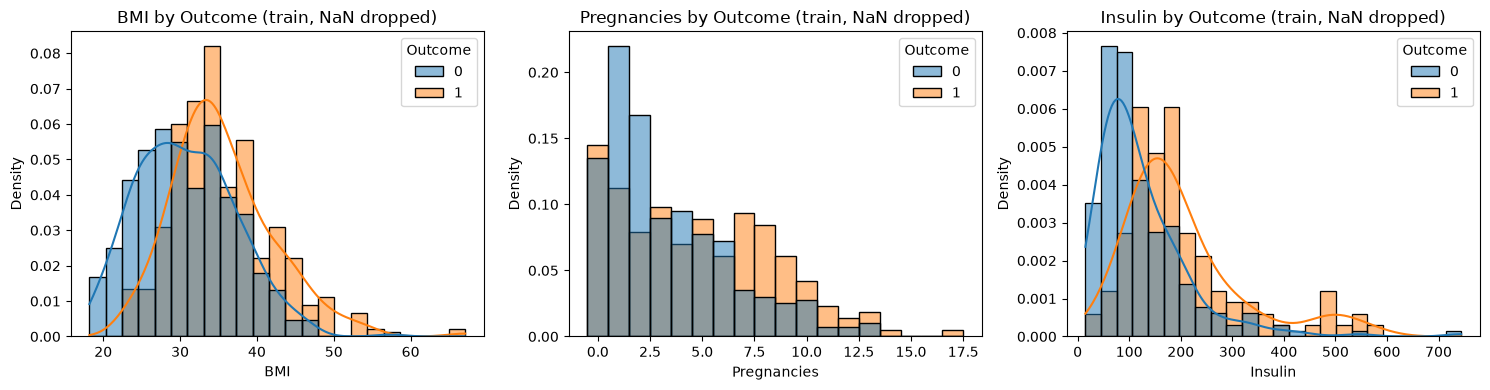

In [24]:
HYPOTHESIS_COLUMNS = ["BMI", "Pregnancies", "Insulin"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, HYPOTHESIS_COLUMNS):
    sns.histplot(
        data=df_train, x=col, hue="Outcome", stat="density", common_norm=False,
        discrete=(col == "Pregnancies"), kde=(col != "Pregnancies"), ax=ax,
    )
    ax.set_title(f"{col} by Outcome (train, NaN dropped)")
plt.tight_layout()
plt.show()

In [25]:
# Shapiro per group: with n in the hundreds, read it together with the histogram and the skew
rows = []
for col in ["BMI", "Insulin"]:
    for outcome, values in df_train.groupby("Outcome")[col]:
        values = values.dropna()
        w, p = stats.shapiro(values)
        rows.append({"column": col, "Outcome": outcome, "n": len(values),
                     "skew": round(values.skew(), 2), "Shapiro W": round(w, 3), "Shapiro p": p})
pd.DataFrame(rows)

,column,Outcome,n,skew,Shapiro W,Shapiro p
0,BMI,0,393,0.40,0.984,2.788306e-04
1,BMI,1,212,0.95,0.955,2.965267e-06
2,Insulin,0,215,2.69,0.781,1.212527e-16
3,Insulin,1,109,1.52,0.847,2.948169e-09


### 4.3 Overview: all columns after 0 → NaN

Training set only, NaNs dropped per column (nothing is filled yet). The boxplots compare the two `Outcome` groups and mark outlier candidates (points beyond 1.5 × IQR). Outlier candidates are not deletion orders: first check whether a value is biologically possible.

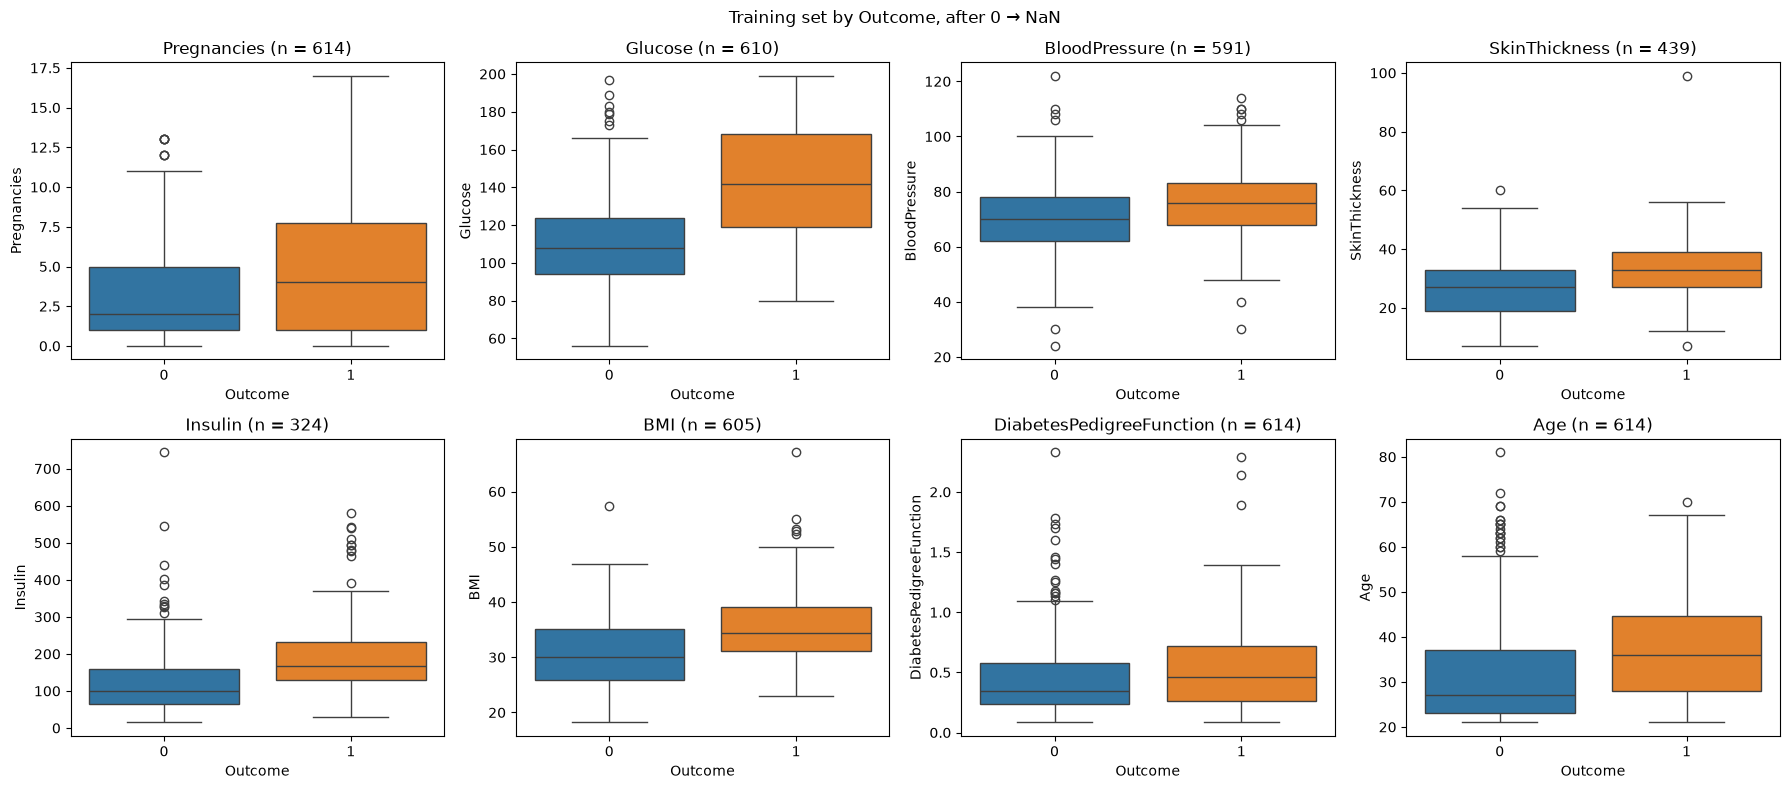

In [26]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, FEATURES):
    sns.boxplot(data=df_train, x="Outcome", y=col, hue="Outcome", legend=False, ax=ax)
    ax.set_title(f"{col} (n = {df_train[col].notna().sum()})")
plt.suptitle("Training set by Outcome, after 0 → NaN")
plt.tight_layout()
plt.show()

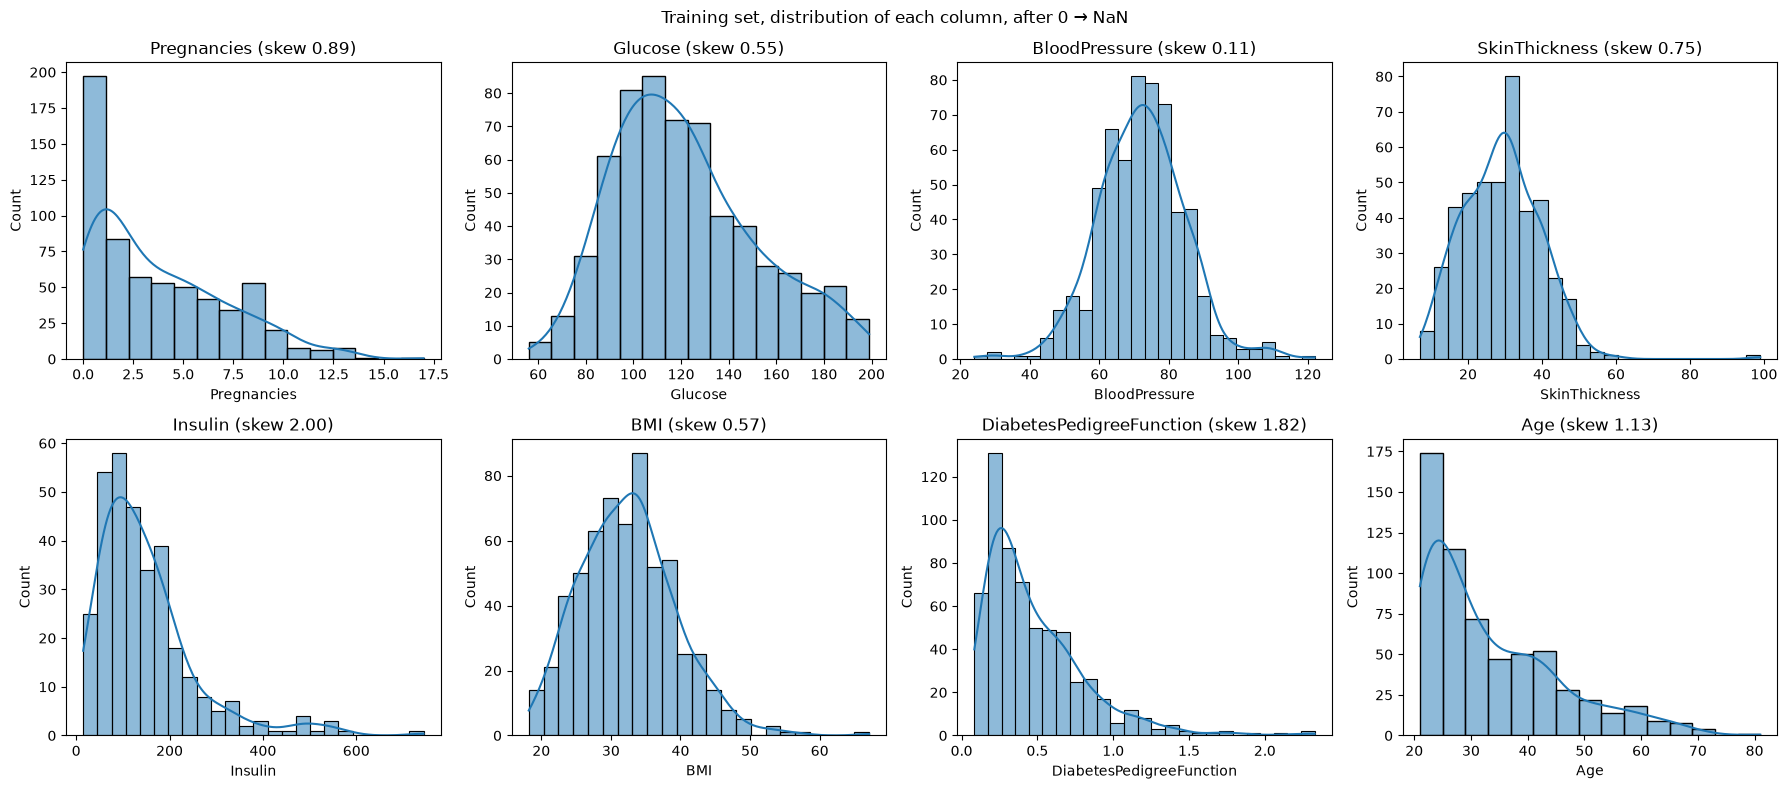

In [27]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, FEATURES):
    sns.histplot(data=df_train, x=col, kde=True, ax=ax)
    ax.set_title(f"{col} (skew {df_train[col].skew():.2f})")
plt.suptitle("Training set, distribution of each column, after 0 → NaN")
plt.tight_layout()
plt.show()

In [28]:
df_train[FEATURES].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,614.0,3.82,3.31,0.00,1.00,3.00,6.00,17.00
Glucose,610.0,121.70,30.10,56.00,99.00,117.00,140.75,199.00
BloodPressure,591.0,72.15,12.51,24.00,64.00,72.00,80.00,122.00
SkinThickness,439.0,29.06,10.52,7.00,21.00,29.00,36.00,99.00
Insulin,324.0,149.08,107.23,15.00,76.00,125.00,183.50,744.00
BMI,605.0,32.45,6.87,18.20,27.60,32.40,36.60,67.10
DiabetesPedigreeFunction,614.0,0.48,0.33,0.08,0.24,0.38,0.64,2.33
Age,614.0,33.37,11.83,21.00,24.00,29.00,41.00,81.00


In [ ]:
# Your code here

